In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils import load_config, get_config_path, get_project_root, load_csv

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

pd.set_option('display.max_colwidth', None)


In [37]:
config_path = get_config_path()
config = load_config(str(config_path))
project_root = get_project_root()
predictions_path = (project_root / config["data"]["local_predictions_path"]).resolve()
text_column = config["task"]["text_column"]
label_column = config["task"]["label_column"]

In [38]:
df = load_csv(predictions_path)

In [39]:
df.head()

,Text,Text_raw,Category,Prediction
0,putas religiones,En todas las putas religiones ahí nos vamos a ver 😏\n,0,0
1,jajaja mames pongas ponemos grupo bye putos,"JAJAJA no mames, aquí no pongas eso y por algo será, nos ponemos de acuerdo en el grupo mejor bye putos\n",0,1
2,sublime tweet denle 10 tacos 10 chelas cabrona jajajajajajajajaja,@USUARIO @USUARIO 👏👏👏SUBLIME TWEET! 🙌denle 10 tacos y 10 chelas a esta cabrona JAJAJAJAJAJAJAJAJA\n,0,0
3,quiero puto café llorar desestresarmeampno pensar,"Quiero un puto café, llorar, desestresarme&amp;no pensar en nada 🤦😫\n",0,0
4,cogiendo conque cogida metió cogida gay safesex,Cogiendo conQue buena cogida me metió 👌🏼🤤 #Cogida #Gay #SafeSex\n,0,0


## Compute evaluation metrics

In [40]:
y_test = df[label_column]
y_pred = df["Prediction"]

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

Accuracy: 0.8350374914792092
Precision: 0.7295918367346939
Recall: 0.6777251184834123
F1 Score: 0.7027027027027027


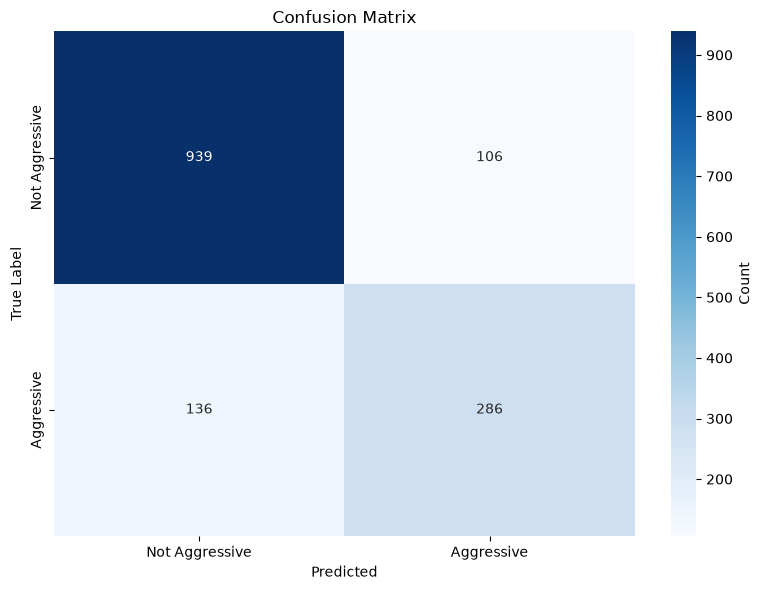

In [42]:
cm = confusion_matrix(df["Category"], df["Prediction"])

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Aggressive', 'Aggressive'],
            yticklabels=['Not Aggressive', 'Aggressive'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [43]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.87      0.90      0.89      1045
           1       0.73      0.68      0.70       422

    accuracy                           0.84      1467
   macro avg       0.80      0.79      0.79      1467
weighted avg       0.83      0.84      0.83      1467



## Error analysis

In [44]:
df[df["Category"] != df["Prediction"]][[text_column, "Text_raw", label_column, "Prediction"]].head(10)

,Text,Text_raw,Category,Prediction
1,jajaja mames pongas ponemos grupo bye putos,"JAJAJA no mames, aquí no pongas eso y por algo será, nos ponemos de acuerdo en el grupo mejor bye putos\n",0,1
10,pinche edad andar leyendo pinches putas diapositivas verga chingadamadre,Y ya no están en la pinche edad para andar leyendo LAS PINCHES PUTAS DIAPOSITIVAS DE LA VERGA CHINGADAMADRE \n,0,1
13,encabronada pseudo feministas tontas iletradas avergüenza mujer preferiría falo niunamas,"Estoy muy encabronada con las pseudo feministas por tontas e iletradas, a veces me avergüenza ser mujer; preferiría tener un falo. #NiUnaMas\n",1,0
15,gracias catalanes habéis conseguido putos fachas dejen sentir vergüenza serlo,"Gracias catalanes, habéis conseguido que los putos fachas dejen de sentir vergüenza de serlo.\n",0,1
32,viejas exigentes piden cenas románticas restaurantes lujo mamen pendejas confórmense tacos canasta putas,"Hay viejas exigentes que piden cenas románticas en restaurantes de lujo, no mamen pendejas, confórmense con unos tacos de canasta, putas.\n",1,0
36,crees sexy estás gorda,Tu! La que te crees sexy y estás gorda!\n,1,0
42,funciona indiferencia ignoras vas verga l,Conmigo no funciona la indiferencia. A mí me ignoras y te vas a la verga .l.\n,1,0
45,traicionó pueblo méxico partido aliarse víboras prietas prometió combatir lanza alfonso romo,"Quién traicionó al pueblo de México y a su partido, para aliarse con las víboras prietas que prometió combatir; se lanza contra Alfonso Romo \n",0,1
52,alcalde palma mallorca españa putos cojones,El alcalde de Palma de Mallorca: “¡Estoy de España hasta los putos cojones!”\n,0,1
57,fea criticando feas,"La fea criticando a ""feas"". 😂😂🤦🏻‍♀️\n",0,1
